# KDDM1 Project - Part 2

In [50]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Load Data

First, the new data is loaded and preprocessed where necessary. Then it is merged with the already preprocessed data from part 1.

In [6]:
import pandas as pd

data: pd.DataFrame = pd.read_pickle("data/processed/data.pkl")
df_target = pd.read_csv("data/missing_link.csv")

df_target['helmet_brand'] = df_target['helmet_brand'].astype('category')
df_target['tape_color'] = df_target['tape_color'].astype('category')
df_target['pregame_music_genre'] = df_target['pregame_music_genre'].astype('category')
df_target['locker_room_role'] = df_target['locker_room_role'].astype('category')
df_target['uses_tinted_visor'] = df_target['uses_tinted_visor'].map({1: True, 0: False})
df_target['left_skate_first'] = df_target['left_skate_first'].map({1: True, 0: False})
df_target['brings_backup_stick'] = df_target['brings_backup_stick'].map({1: True, 0: False})
df_target['morning_skate_attended'] = df_target['morning_skate_attended'].map({1: True, 0: False})

df_target = df_target.rename(columns={'0x676f6c64656e5f7469707073': 'golden_tipps'})
df_target['golden_tipps'] = pd.Categorical(
  df_target['golden_tipps'], 
  categories=sorted(df_target['golden_tipps'].dropna().unique()), 
  ordered=True
)

data = data.merge(df_target, on="international_id", how="inner")
target = data['selection_probability']

## 2. Feature Selection

Next we select the features that are later provided to our models. For this we want to use the ones that show some correlation with our target column `selection_probability`.

To get the multiple different correlation metrics for all feature pairs, we save `data` to `data/processed/data_2.csv` and provide it to the `analysis.py` script one of us already created for Homework 1.

In [7]:
data.to_csv("data/processed/data_2.csv")

The resulting `correlations` frame is reformated.

In [8]:
import numpy as np

correlations = pd.read_csv('output/correlation.csv')

correlations[['feature1', 'feature2']] = np.sort(correlations[['feature1', 'feature2']], axis=1)

correlations_pivot = correlations.pivot_table(index=["feature1", "feature2"], columns="method", values="score", aggfunc="first")
max_score = correlations.pivot_table(index=["feature1", "feature2"], columns="method", values="score_abs", aggfunc="first").max(axis=1)
correlations_pivot["max_abs_score"] = max_score
correlations_pivot = correlations_pivot.sort_values("max_abs_score", ascending=False).reset_index()
correlations_pivot.columns.name = None
correlations_pivot = correlations_pivot[['max_abs_score'] + [col for col in correlations_pivot.columns if col != 'max_abs_score']]

correlations = correlations_pivot

correlations.head(10)

,max_abs_score,feature1,feature2,cramers_v,distance_correlation,eta_squared,mutual_information_cat_cat,mutual_information_cat_num,mutual_information_num_num,pearson,spearman
0,1.000000,Unnamed: 0,international_id,NaN,1.000000,NaN,NaN,NaN,0.999579,1.000000,1.000000
1,1.000000,avg_shoot_speed,shot_power_score,NaN,1.000000,NaN,NaN,NaN,0.999362,1.000000,1.000000
2,0.997020,goals_against_average,goals_against_total,NaN,0.979523,NaN,NaN,NaN,0.440309,0.955297,0.997020
3,0.995936,age,draft_year,NaN,0.993854,NaN,NaN,NaN,0.930081,-0.976589,-0.995936
4,0.976642,goals,shooting_percentage_calculated,NaN,0.961323,NaN,NaN,NaN,0.891807,0.780672,0.976642
5,0.957563,passes_attempted,puck_touches,NaN,0.951815,NaN,NaN,NaN,0.654341,0.957563,0.885392
6,0.917059,height,shoe_size,NaN,0.889238,NaN,NaN,NaN,0.602572,0.917059,0.910329
7,0.878114,goals,power_play_goals,NaN,0.837992,NaN,NaN,NaN,0.516387,0.878114,0.854782
8,0.877112,years_played,years_pro,NaN,0.877112,NaN,NaN,NaN,0.764634,0.831689,0.766457
9,0.863230,draft_year,years_played,NaN,0.854609,NaN,NaN,NaN,0.565573,-0.851016,-0.863230


Then it is filtered for all correlations found for our target column.

In [9]:
TARGET = 'selection_probability'

target_corr_mask = correlations[['feature1', 'feature2']].isin([TARGET]).any(axis=1)
target_correlations = correlations[target_corr_mask]
target_correlations['feature'] = np.where(target_correlations['feature1'] != TARGET, target_correlations['feature1'], target_correlations['feature2'])
target_correlations = target_correlations.drop(columns=['feature1', 'feature2'])
target_correlations = target_correlations[['feature'] + [col for col in target_correlations.columns if col != 'feature']]

target_correlations = target_correlations.sort_values("max_abs_score", ascending=False).reset_index(drop=True)
selected_features = target_correlations['feature'].to_list()

target_correlations

,feature,max_abs_score,cramers_v,distance_correlation,eta_squared,mutual_information_cat_cat,mutual_information_cat_num,mutual_information_num_num,pearson,spearman
0,golden_tipps,0.585042,NaN,NaN,0.201738,NaN,0.585042,NaN,NaN,NaN
1,won_championship,0.247356,NaN,0.236323,0.059669,NaN,NaN,NaN,0.244272,0.247356
2,training_pct,0.191352,NaN,0.161780,NaN,NaN,NaN,0.191352,NaN,NaN
3,experience_level,0.159327,NaN,NaN,0.159327,NaN,0.083674,NaN,NaN,NaN
4,goals,0.158686,NaN,0.158686,NaN,NaN,NaN,0.072773,-0.056179,NaN
5,shooting_percentage_calculated,0.149590,NaN,0.149590,NaN,NaN,NaN,0.058688,NaN,NaN
6,school_grade,0.143144,NaN,0.143144,NaN,NaN,NaN,0.078715,NaN,NaN
7,captain,0.141343,NaN,0.136778,NaN,NaN,NaN,NaN,-0.140423,-0.141343
8,number_of_previous_teams,0.124684,NaN,0.124684,NaN,NaN,NaN,NaN,-0.097372,-0.088395
9,avg_shoot_speed,0.118703,NaN,0.102295,NaN,NaN,NaN,0.118703,NaN,NaN


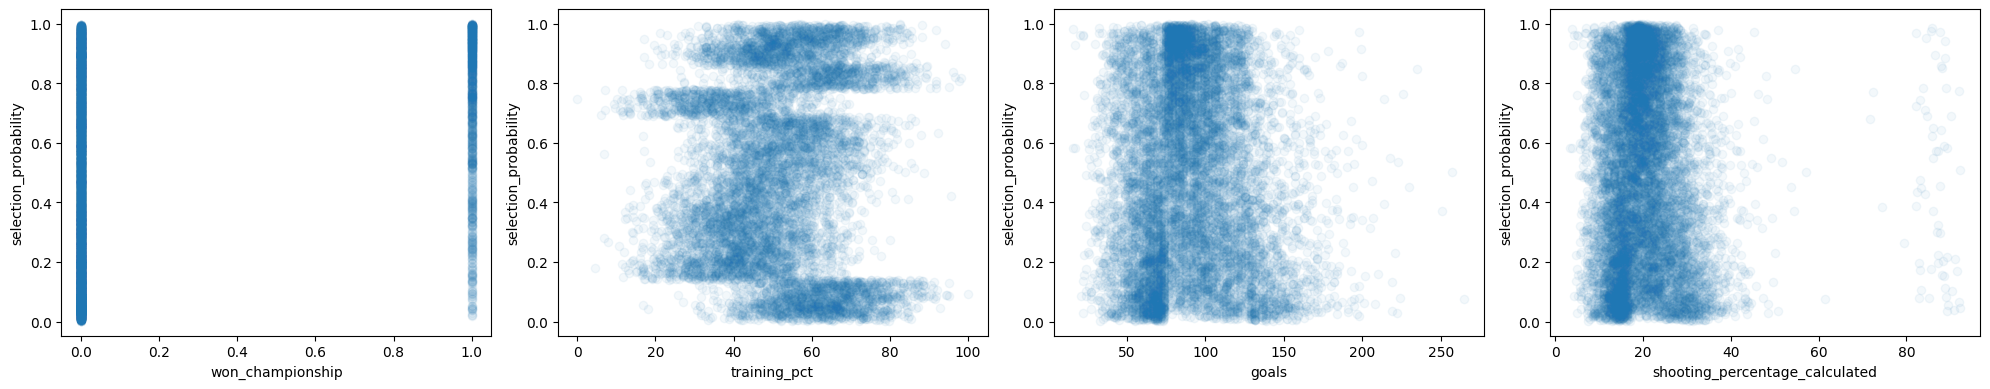

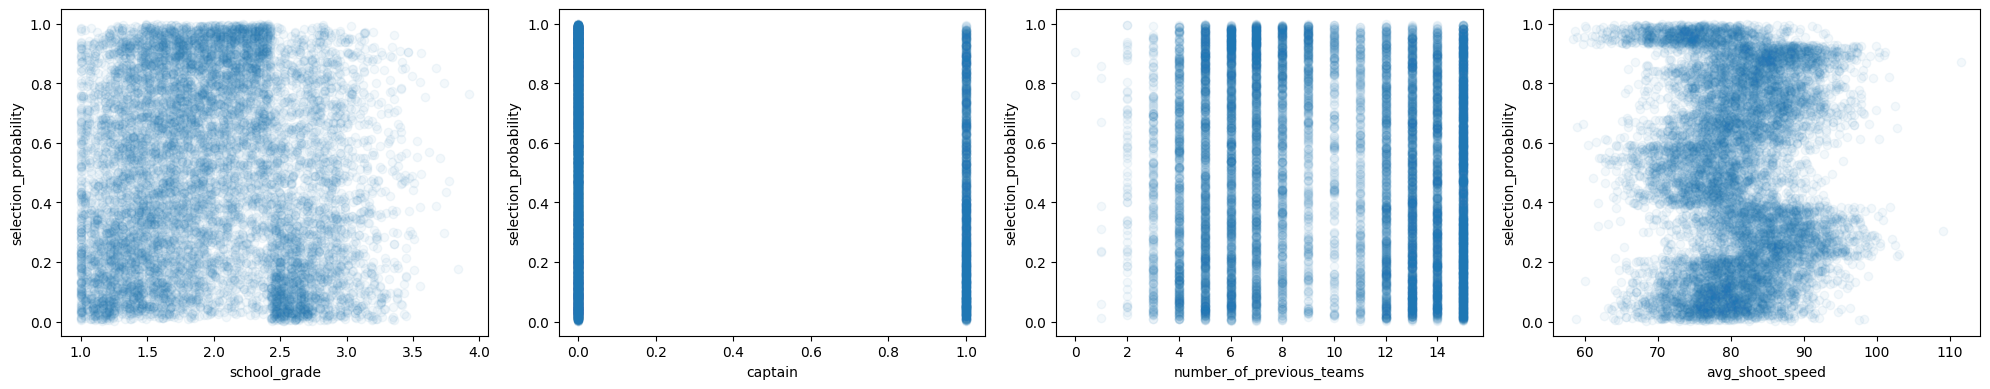

In [10]:
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

features = target_correlations['feature'].to_list()[:10]
features = [feature for feature in features if feature in data.columns and is_numeric_dtype(data[feature])]

features_per_plot = 4

for start in range(0, len(features), features_per_plot):
  feature_chunk = features[start:start + features_per_plot]

  fig, axes = plt.subplots(1, len(feature_chunk), figsize=(5 * len(feature_chunk), 4))

  for i, feature in enumerate(feature_chunk):
    target_values = data[TARGET]
    feature_values = data[feature]

    axes[i].scatter(feature_values, target_values, alpha=0.05)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(TARGET)

  plt.tight_layout()
  plt.show()

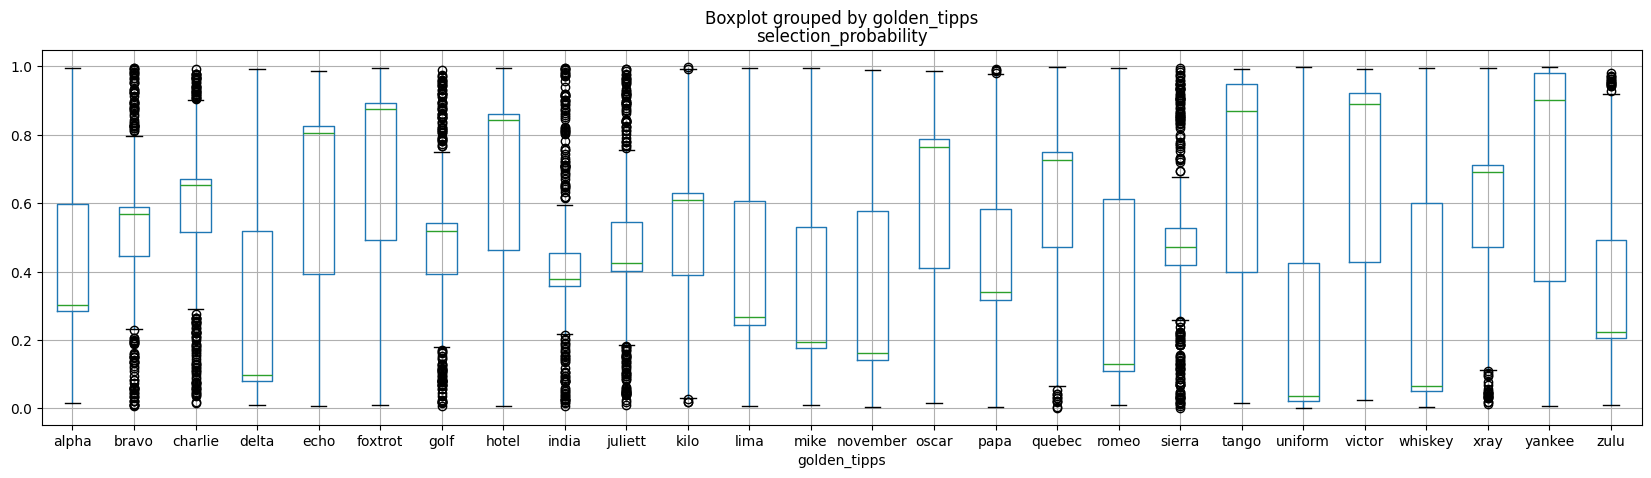

In [11]:
data.boxplot(column=TARGET, by='golden_tipps', figsize=(20, 5))
plt.show()

Before we select them as the feature columns for our models, we try to prune them further by searching for significant correlations between one another. If one feature is already sufficiently explained by another (very high correlation) we can drop it to reduce the complexity of later models.

In [12]:
selected_feature_corr_mask = correlations[['feature1', 'feature2']].isin(selected_features).all(axis=1)
selected_feature_correlations = correlations[selected_feature_corr_mask]

selected_feature_correlations

,max_abs_score,feature1,feature2,cramers_v,distance_correlation,eta_squared,mutual_information_cat_cat,mutual_information_cat_num,mutual_information_num_num,pearson,spearman
1,1.000000,avg_shoot_speed,shot_power_score,NaN,1.000000,NaN,NaN,NaN,0.999362,1.000000,1.000000
4,0.976642,goals,shooting_percentage_calculated,NaN,0.961323,NaN,NaN,NaN,0.891807,0.780672,0.976642
7,0.878114,goals,power_play_goals,NaN,0.837992,NaN,NaN,NaN,0.516387,0.878114,0.854782
13,0.836567,power_play_goals,shooting_percentage_calculated,NaN,0.809551,NaN,NaN,NaN,0.496582,0.687317,0.836567
14,0.835161,experience_level,number_of_previous_teams,NaN,NaN,0.835161,NaN,0.499452,NaN,NaN,NaN
18,0.782007,fitness_level,pass_completion_rate,NaN,NaN,0.782007,NaN,0.539134,NaN,NaN,NaN
22,0.717277,captain,power_play_goals,NaN,0.717277,0.505530,NaN,0.318597,NaN,0.711006,0.616174
30,0.648334,captain,goals,NaN,0.634437,0.420337,NaN,0.220703,NaN,0.648334,0.566054
34,0.611844,captain,shooting_percentage_calculated,NaN,0.611844,0.250831,NaN,0.215536,NaN,0.500830,0.553378
35,0.600917,number_of_previous_teams,years_played,NaN,0.493604,NaN,NaN,NaN,0.317858,0.526936,0.600917


We decide to only drop feature if there are correlations with a value of 0.95 or higher. For each pair we drop the feature with the lower correlation to the target column.

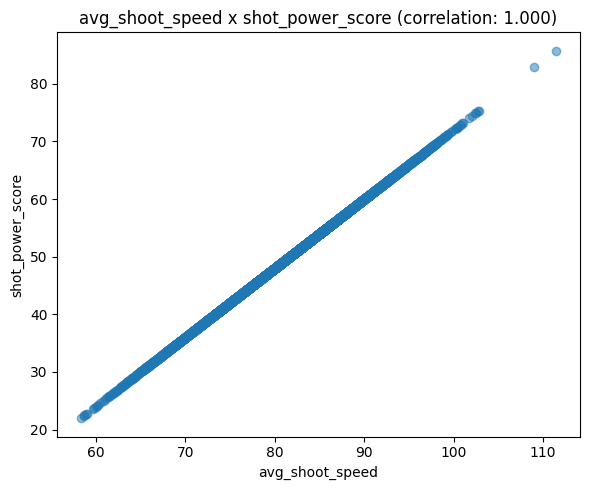

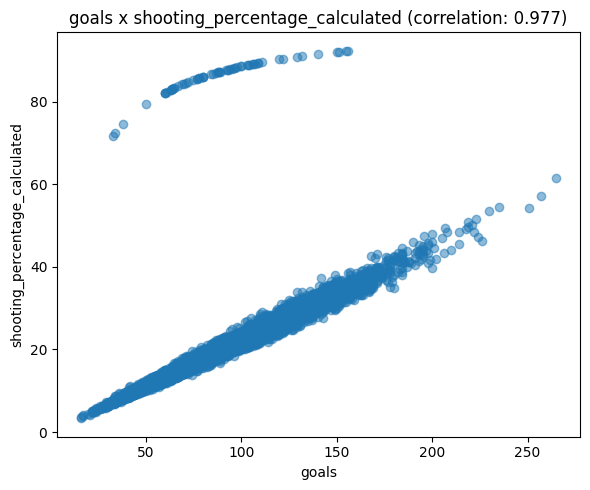

,feature,max_abs_score,cramers_v,distance_correlation,eta_squared,mutual_information_cat_cat,mutual_information_cat_num,mutual_information_num_num,pearson,spearman
5,shooting_percentage_calculated,0.149590,NaN,0.149590,NaN,NaN,NaN,0.058688,NaN,NaN
11,shot_power_score,0.113035,NaN,0.103286,NaN,NaN,NaN,0.113035,NaN,NaN


In [13]:
import matplotlib.pyplot as plt

SIGNIFICANT_INTER_FEATURE_CORR = 0.95

significant_inter_feature_corr = selected_feature_correlations[
  selected_feature_correlations['max_abs_score'] >= SIGNIFICANT_INTER_FEATURE_CORR
]

target_score = target_correlations.set_index("feature")["max_abs_score"]
redundant_features = []
for _, row in significant_inter_feature_corr.iterrows():
  f1 = row["feature1"]
  f2 = row["feature2"]

  f1_score = target_score[f1]
  f2_score = target_score[f2]

  if f1_score >= f2_score:
    redundant_features.append(f2)
    selected_features.remove(f2)
  else:
    redundant_features.append(f1)
    selected_features.remove(f1)

  plt.figure(figsize=(6, 5))
  plt.scatter(data[f1], data[f2], alpha=0.5)
  plt.xlabel(f1)
  plt.ylabel(f2)
  plt.title(f"{f1} x {f2} (correlation: {row['max_abs_score']:.3f})")
  plt.tight_layout()
  plt.show()

target_correlations[target_correlations[['feature']].isin(redundant_features).any(axis=1)]

We are left with the following remaining columns in `selected_features` for model training and target value prediction:

In [14]:
target_correlations[target_correlations[['feature']].isin(selected_features).any(axis=1)]

,feature,max_abs_score,cramers_v,distance_correlation,eta_squared,mutual_information_cat_cat,mutual_information_cat_num,mutual_information_num_num,pearson,spearman
0,golden_tipps,0.585042,NaN,NaN,0.201738,NaN,0.585042,NaN,NaN,NaN
1,won_championship,0.247356,NaN,0.236323,0.059669,NaN,NaN,NaN,0.244272,0.247356
2,training_pct,0.191352,NaN,0.161780,NaN,NaN,NaN,0.191352,NaN,NaN
3,experience_level,0.159327,NaN,NaN,0.159327,NaN,0.083674,NaN,NaN,NaN
4,goals,0.158686,NaN,0.158686,NaN,NaN,NaN,0.072773,-0.056179,NaN
6,school_grade,0.143144,NaN,0.143144,NaN,NaN,NaN,0.078715,NaN,NaN
7,captain,0.141343,NaN,0.136778,NaN,NaN,NaN,NaN,-0.140423,-0.141343
8,number_of_previous_teams,0.124684,NaN,0.124684,NaN,NaN,NaN,NaN,-0.097372,-0.088395
9,avg_shoot_speed,0.118703,NaN,0.102295,NaN,NaN,NaN,0.118703,NaN,NaN
10,pass_completion_rate,0.117928,NaN,0.117928,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
training_data = data[selected_features]
training_data.head(10)

,golden_tipps,won_championship,training_pct,experience_level,goals,school_grade,captain,number_of_previous_teams,avg_shoot_speed,pass_completion_rate,power_play_goals,fitness_level,jersey_number,years_played
0,xray,False,64.807142,sophomore,108,2.32,False,6,91.74,38.95,120,Average,59,6
1,foxtrot,False,60.258916,rookie,48,2.16,False,9,94.18,61.54,60,NaN,26,9
2,whiskey,False,29.876669,veteran,83,1.24,False,12,80.46,75.00,110,Good,89,9
3,lima,False,41.177986,rookie,87,1.33,False,7,90.87,57.19,112,Good,4,9
4,tango,False,67.248762,sophomore,108,2.74,False,7,81.37,69.38,110,Excellent,47,6
5,victor,False,50.494823,rookie,90,1.05,True,6,94.08,52.55,139,Good,59,7
6,papa,False,NaN,sophomore,91,1.92,False,7,84.84,87.64,102,Excellent,86,7
7,zulu,True,28.662456,veteran,155,1.68,True,15,78.15,48.48,163,Average,88,11
8,juliett,False,27.326114,veteran,92,1.16,False,15,73.08,52.52,109,Average,37,11
9,xray,False,50.933166,veteran,64,1.47,False,14,82.97,45.97,101,Average,92,5


## 3. Training Preparation

We start by building a feature matrix X from selected_features and the target y (selection_probability), then splitting it into a training set (80%) and a test set (20%). This same split is reused for the baselines and for every model trained in the next section.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

X = data[selected_features]
y = target.copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist() # all int64 or float64
bool_features = X.select_dtypes(include=["bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["category"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Then we specify the evaluation. The main performance metric will be **Root Mean Squared Error (RMSE)**. During validation we want to use KFold with `k=5` in order to not use any additional training data.

In [17]:
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

scoring_function = root_mean_squared_error

# testing
results = pd.DataFrame(columns=["model", "RMSE", "MAE", "R2"])
def test_model(name, y_true, y_pred):
  global results
  row = pd.DataFrame([{
    "model": name,
    "RMSE": root_mean_squared_error(y_true, y_pred),
    "MAE": mean_absolute_error(y_true, y_pred),
    "R2": r2_score(y_true, y_pred),
  }])
  results = pd.concat([results, row], ignore_index=True)

def test_results_df():
  return results.sort_values("RMSE", ascending=True).reset_index(drop=True)

# validation
validation_cv = KFold(n_splits=5, shuffle=True)

from sklearn.model_selection import KFold, cross_validate

validation_cv = KFold(n_splits=5, shuffle=True, random_state=42)

def validate_model(model, X_train, y_train):
  scores = cross_validate(model, X_train, y_train, cv=validation_cv, n_jobs= -1,
    scoring={
      "RMSE": "neg_root_mean_squared_error",
      "MAE": "neg_mean_absolute_error",
      "R2": "r2",
    }
  )

  rmse_scores = -scores["test_RMSE"]
  mae_scores = -scores["test_MAE"]
  r2_scores = scores["test_R2"]

  return pd.DataFrame([{
    "RMSE_mean": rmse_scores.mean(),
    "RMSE_std": rmse_scores.std(),
    "MAE_mean": mae_scores.mean(),
    "MAE_std": mae_scores.std(),
    "R2_mean": r2_scores.mean(),
    "R2_std": r2_scores.std(),
  }])

Here we add some additional helper functions to analyze models.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from matplotlib.ticker import MaxNLocator

def plot_learning_curves(model, X, y):
  train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
  )

  train_rmse, val_rmse = np.sqrt(-train_scores), np.sqrt(-val_scores)
  train_mean, val_mean = train_rmse.mean(axis=1), val_rmse.mean(axis=1)
  train_std, val_std = train_rmse.std(axis=1), val_rmse.std(axis=1)

  plt.plot(train_sizes, train_mean, label="Training RMSE")
  plt.plot(train_sizes, val_mean, label="Validation RMSE")
  plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
  plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

  plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=15))
  plt.xlabel("Training set size")
  plt.ylabel("RMSE")
  plt.title("Learning curve")
  plt.legend()
  plt.show()

## 4. Baselines

Baseline 1 is Constant: the simplest possible "model" ignores every feature and always predicts the average selection_probability from the training data. Any real model that performs worse than this isn't learning anything useful.

In [19]:
from sklearn.dummy import DummyRegressor

dummy_mean = DummyRegressor(strategy="mean")
dummy_mean.fit(X_train, y_train)
test_model("Constant (mean)", y_test, dummy_mean.predict(X_test))

Baseline 2 is Random: also ignores the features, but predicts a random number between 0 and 1 (since selection_probability is a probability) instead of a fixed value. This typically performs worse than the constant baseline.

In [20]:
import numpy as np

y_pred_random = np.random.uniform(low=0, high=1, size=len(y_test))
test_model("Random (uniform)", y_test, y_pred_random)

Baseline 3 is Linear Regression: the first baseline that actually uses selected features. Since these columns contain missing values and a mix of numeric, boolean, and categorical types, we build a small preprocessing pipeline first
numeric columns are median imputed and scaled, categorical columns are imputed with a constant "missing" category and one hot encoded, and boolean columns pass through unchanged.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
    ("bool", "passthrough", bool_features),
])

linear_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
linear_baseline.fit(X_train, y_train)
test_model("Linear Regression", y_test, linear_baseline.predict(X_test))

In [22]:
#results
test_results_df()

,model,RMSE,MAE,R2
0,Linear Regression,0.230013,0.185124,0.430653
1,Constant (mean),0.304838,0.269922,-0.000023
2,Random (uniform),0.425584,0.347889,-0.949141


## 5. Model Training

### XGBoost

* no missing value imputation required, as it can handle this on its own

First we want to analyze how the `n_estimators` and the `learning_rate` influence the score of the model. For this we run a grid search across a selection of values for both parameters.

In [23]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

hyper_params = {
  'n_estimators': [100, 300, 500, 1000, 2000],
  'learning_rate': [0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2]
}

first_xgb_model = GridSearchCV(
  XGBRegressor(enable_categorical=True), 
  param_grid=hyper_params, scoring='neg_root_mean_squared_error',
  cv=validation_cv,
  n_jobs=-1
)
first_xgb_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.001, 0.005, ...], 'n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

One can see that for each `n_estimators` value there is a `learning_rate` sweetspot. The higher the n_estimators, the smaller the learning_rate may be, before the error rate increases again rapidly. We will now carry the best model found further to the next experiments.

best found hyper-parameters: {'learning_rate': 0.01, 'n_estimators': 1000}


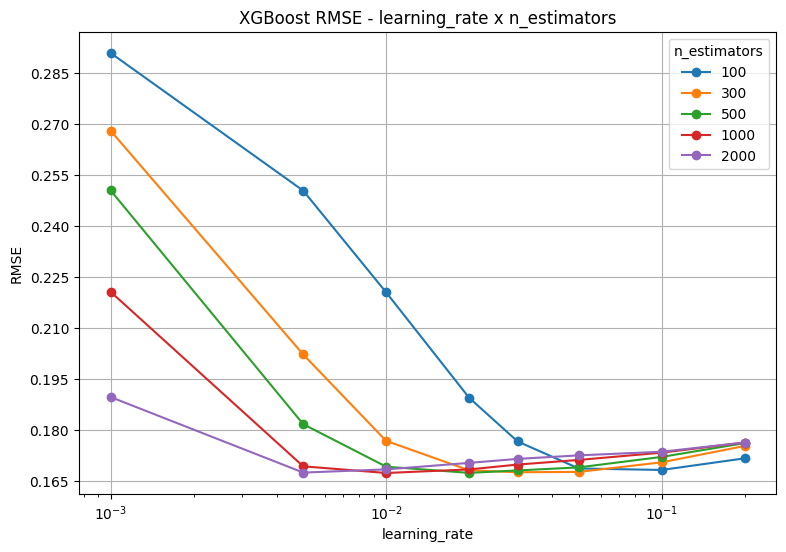

In [24]:
from matplotlib.ticker import MaxNLocator


xgb_cv_results = pd.DataFrame(first_xgb_model.cv_results_)
xgb_cv_results["rmse"] = -xgb_cv_results["mean_test_score"]

print(f"best found hyper-parameters: " + str(first_xgb_model.best_params_))

plt.figure(figsize=(9, 6))

for n_est, subset in xgb_cv_results.groupby("param_n_estimators"):
  subset = subset.sort_values("param_learning_rate")

  plt.plot(subset["param_learning_rate"], subset["rmse"], marker="o", label=f"{n_est}")

plt.xscale("log")
plt.xlabel("learning_rate")
plt.ylabel("RMSE")
plt.title("XGBoost RMSE - learning_rate x n_estimators")
plt.grid(True)
plt.legend(title="n_estimators")

ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

plt.show()

first_best_xgb_model = first_xgb_model.best_estimator_

At this point we want to check whether the training data is sufficient.

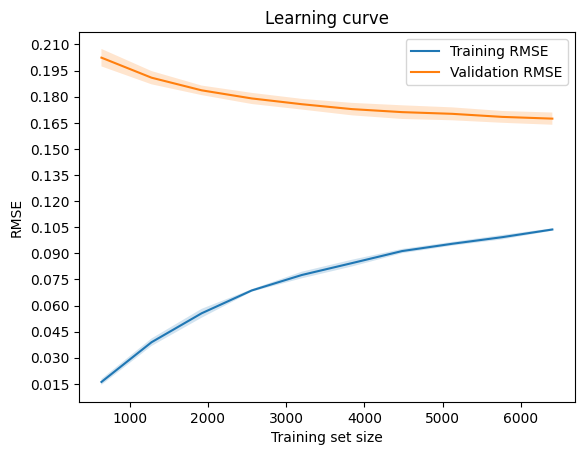

In [25]:
plot_learning_curves(first_best_xgb_model, X_train, y_train)

We can see that there is still a considerable gap between the training and validation RMSE. Although more data would reduce the error, we can see that the curve is already flattening. Therefore, we want to try out more regularization. We will run a new round on RandomSearch with the following hyper-parameters that might help: `max_depth`, `min_samples_leaf`, `l2_regularization` and `subsample`.

In [26]:
from scipy.stats import randint, loguniform, uniform
from sklearn.model_selection import RandomizedSearchCV

hyper_params = {
  'max_depth': randint(2, 8),
  'min_child_weight': randint(1, 20),
  'reg_lambda': loguniform(1e-3, 100),
  'subsample': uniform(0.5, 0.5),
}

next_xgb_model = RandomizedSearchCV(
  estimator=first_best_xgb_model,
  n_iter=50,
  param_distributions=hyper_params, 
  scoring='neg_root_mean_squared_error',
  cv=validation_cv,
  n_jobs=-1
)
next_xgb_model.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....x7c7a4abd74d0>, 'min_child_weight': <scipy.stats....x7c7a0f791f90>, 'reg_lambda': <scipy.stats....x7c7a4abd7380>, 'subsample': <scipy.stats....x7c7a0f7939d0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:

In [27]:
best_xgb_model = next_xgb_model.best_estimator_
print(f"best found hyper-parameters: " + str(next_xgb_model.best_params_))

display(validate_model(best_xgb_model, X_train, y_train))

best found hyper-parameters: {'max_depth': 6, 'min_child_weight': 9, 'reg_lambda': np.float64(0.4326886284174353), 'subsample': np.float64(0.5015776752229243)}


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,0.163653,0.002482,0.125327,0.002213,0.711701,0.011077


Lets check the learning curves again.

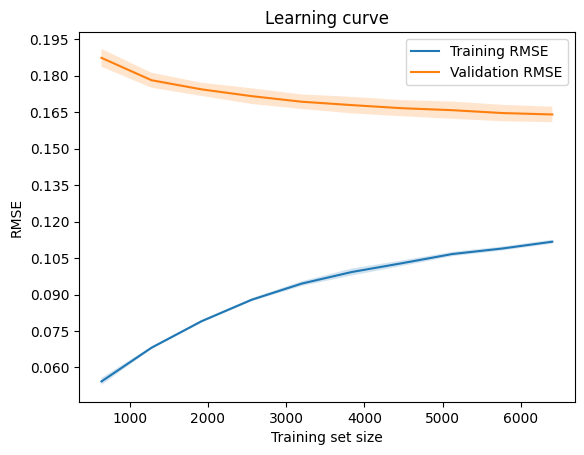

In [28]:
plot_learning_curves(best_xgb_model, X_train, y_train)

This managed to decrease the RMSE again a bit more and we will keep this as the best XGBoost model.

In [29]:
test_model("XGBoost", y_test, best_xgb_model.predict(X_test))

### Gaussian Process Regression

This model type has some obvious drawbacks for tabular data, so we do not expect any real competitive results. The biggest problem is, that it is heavy on training with too many dimensions and too many rows. Therefore, I will first handpick a subset of the previously picked features.

* no unordered categoricals, as one-hot encoding would result in too many features
* no features that correlate too much already with one another

Secondly, I also found out that one can select kernel for specific properties of the data. Specifically, I tried to select many numeric features that appeared to correlate in smooth curves with the target, as this can also be expressed by specific kernels.

Additionally, I only use a sample of 1000, as the runtime increases cubically with the sample size.

In [30]:
from sklearn.preprocessing import FunctionTransformer

gpr_features = ['goals', 'avg_shoot_speed', 'school_grade']

X_gpr_source = X_train[gpr_features].copy()
X_gpr_source['golden_tipps_num'] = X_train['golden_tipps'].cat.codes + 1

X_gpr_test_source = X_test[gpr_features].copy()
X_gpr_test_source['golden_tipps_num'] = X_test['golden_tipps'].cat.codes + 1

gpr_features = gpr_features + ['golden_tipps_num']

X_gpr_train = X_gpr_source[gpr_features].sample(n=1000, random_state=42)
y_gpr_train = y_train.loc[X_gpr_train.index]

X_gpr_test = X_gpr_test_source[gpr_features]


num_cols = X_gpr_train.select_dtypes(include=["number"]).columns
cat_cols = X_gpr_train.select_dtypes(include=["object", "category"]).columns
bool_cols = X_gpr_train.select_dtypes(include=["bool"]).columns

numeric_preprocessor = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  # ("scaler", StandardScaler())
])

boolean_preprocessor = Pipeline([
  ("to_float", FunctionTransformer(lambda x: x.astype(float))),
  ("imputer", SimpleImputer(strategy='constant', fill_value=False)),
])

X_gpr_train.head()

,goals,avg_shoot_speed,school_grade,golden_tipps_num
443,93,73.37,2.13,24
5633,79,78.60,1.83,16
8656,55,80.54,1.99,23
4397,77,97.85,1.90,22
4137,104,83.01,1.65,10


Here I now select kernels. As I said, I wanted to use kernels that work well with smooth data.

* **Matern:** this kernel works well for smooth, but not perfectly smooth data it worked better then the RBF data
* **WhiteKernel:** model random noise

In [31]:
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel, Matern
from sklearn.gaussian_process import GaussianProcessRegressor

n_features = len(gpr_features)

kernel = (
  ConstantKernel(1.0)
  * Matern(
    length_scale=np.ones(n_features),
    length_scale_bounds=(1e-2, 1e4),
    nu=1.5
  )
  # * RBF(
  #   length_scale=np.ones(n_features),
  #   length_scale_bounds=(1e-2, 1e3)
  # )
  + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))
)

gpr_model = Pipeline([
  ("preprocess", ColumnTransformer([
    ("num", numeric_preprocessor, num_cols),
    ("bool", boolean_preprocessor, bool_cols),
  ])),
  ("model", GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
  ))
])

gpr_model.fit(X_gpr_train, y_gpr_train)

display(validate_model(gpr_model, X_gpr_train, y_gpr_train))

/home/felix/TU/KDDM/kddm-project/venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/felix/TU/KDDM/kddm-project/venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,0.266289,0.007188,0.22563,0.007851,0.221666,0.025491


I tested some of the model parameters and these were the ones that worked best. Still, the performance is worse than our Linear Regression baseline with a long training time. More features or rows did only slightly improve the performance, while the runtime suffered proportionally much more.

But one major benefit of this model is that it can also provide a certainty for a prediction. To test how well that works, I want to plot the uncertainty against the actual error. This should have a high correlation in order to have any benefit.

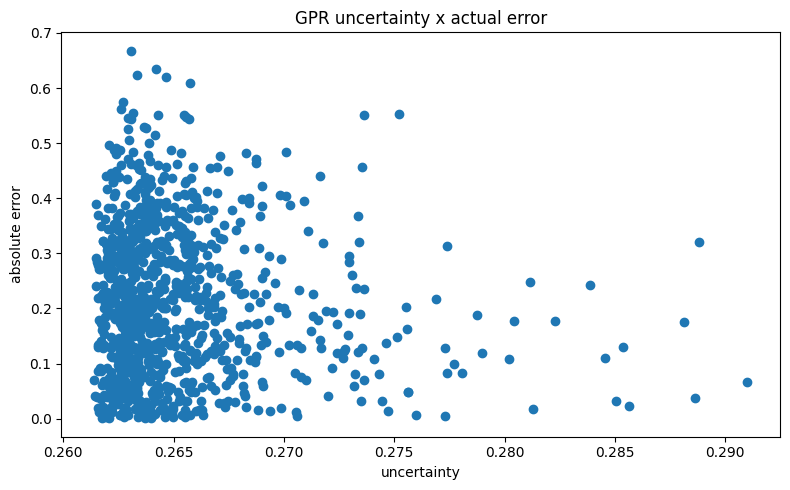

spearman correlation: -0.008724512724512724


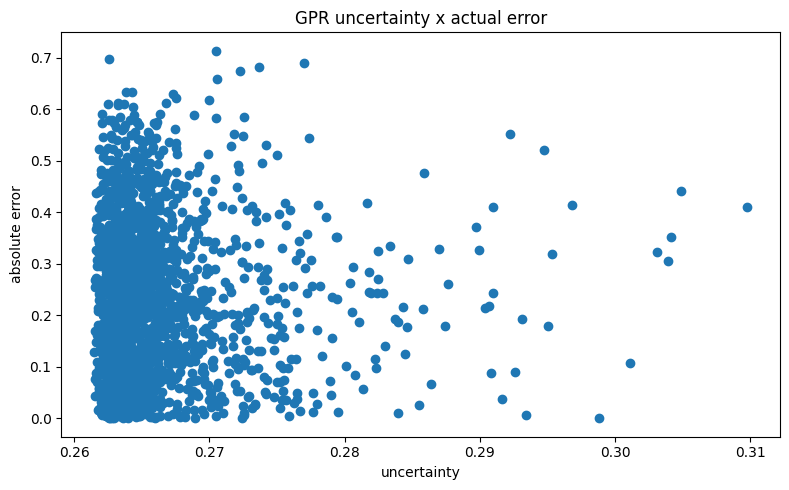

spearman correlation: 0.02791256347814087


In [32]:
from scipy.stats import spearmanr

for (X, y) in [(X_gpr_train, y_gpr_train), (X_gpr_test, y_test)]:
  y_pred, y_std = gpr_model.predict(X, return_std=True)

  actual_error = np.abs(y - y_pred)

  plt.figure(figsize=(8, 5))
  plt.scatter(y_std, actual_error)

  plt.xlabel("uncertainty")
  plt.ylabel("absolute error")
  plt.title("GPR uncertainty x actual error")

  plt.tight_layout()
  plt.show()

  spearman_corr, spearman_p = spearmanr(y_std, actual_error)
  print(f"spearman correlation: {spearman_corr}")

Unfortunately, the correlation does not seem very high. Neither for the training, nor the test data (which normally I shouldn't use here probably). This does not speak for the model.

In [33]:
test_model("Gaussian Process Regression", y_test, gpr_model.predict(X_gpr_test))

### MLP (neural network)
MLP needs the following preprocessing:
- only numeric features can be used, so other types will be converted
- values need to be normalized
- missing values can not be handled, so they need to be imputed or left out. since we did not have any missingness analysis in Phase 1, we will fall back to basic imputation strategies, since this aspect will not be graded a second time.

In [34]:
mlp_numeric_pipe = Pipeline([
  ("impute", SimpleImputer(strategy="median")),
  ("scale", StandardScaler()),
])

mlp_categorical_pipe = Pipeline([
  ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
  ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

mlp_preprocessor = ColumnTransformer([
  ("num", mlp_numeric_pipe, numeric_features),
  ("cat", mlp_categorical_pipe, categorical_features),
  ("bool", "passthrough", bool_features),
])

now we have to find out which hyperparameters are best. That is, what gives the best validation score.
This code section builds my helper function so that I can try out different combinations and see what does and does not make a difference.
Hyperparameter decisions are created based on the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

In [35]:
from sklearn.neural_network import MLPRegressor

mlp_base_model = Pipeline([
  ("preprocessor", mlp_preprocessor),
  ("regressor", MLPRegressor(
    max_iter=1000,
    early_stopping=True,
    random_state=0,
  )),
])

def mlp_param_analysis(param_grid, plot_params=None):
  gridsearch = GridSearchCV(
    mlp_base_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=validation_cv,
    n_jobs=-1,
  )

  gridsearch.fit(X_train, y_train)

  results = pd.DataFrame(gridsearch.cv_results_)
  results["rmse"] = -results["mean_test_score"]

  if plot_params is None:
    plot_params = [p for p, values in param_grid.items() if len(values) > 1][:2]

  x_param, group_param = plot_params
  x_col = "param_" + x_param
  group_col = "param_" + group_param

  print("best found hyper-parameters:", gridsearch.best_params_)

  plt.figure(figsize=(9, 6))

  for value, subset in results.groupby(group_col):
    subset = subset.sort_values(x_col)
    plt.plot(subset[x_col], subset["rmse"], marker="o", label=str(value))

  if pd.api.types.is_numeric_dtype(results[x_col]) and (results[x_col] > 0).all():
    plt.xscale("log")

  plt.xlabel(x_param.replace("regressor__", ""))
  plt.ylabel("RMSE")
  plt.title(f"MLP RMSE - {x_param} x {group_param}")
  plt.grid(True)
  plt.legend(title=group_param.replace("regressor__", ""))
  plt.show()

  return gridsearch, results

---

First test: hidden layer sizes and alpha
- hidden layer sizes is the number and size of the hidden layers. More neurons can capture more complex relationships, but too much can lead to overfitting. **default=(100,)**
- alpha is the "Strength of the L2 regularization term.". It penalizes large weights in the neural network, and that can mitigate overfitting. **default=0.0001**

best found hyper-parameters: {'regressor__alpha': 0.3, 'regressor__hidden_layer_sizes': (128, 64, 32)}


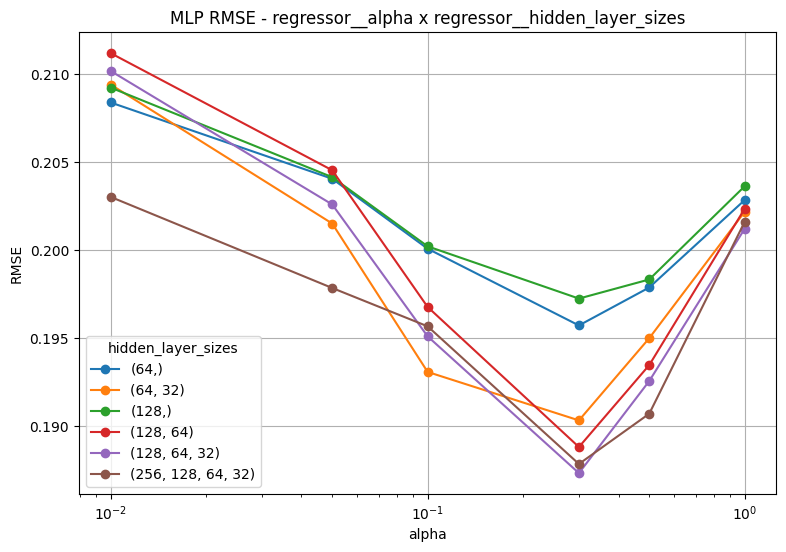

In [39]:
mlp_param_grid = {
  "regressor__alpha": [0.01, 0.05, 0.1, 0.3, 0.5, 1],
  "regressor__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (128, 64, 32), (256, 128, 64, 32)],
}

mlp_gridsearch, mlp_results = mlp_param_analysis(mlp_param_grid)

It can be seen that the sweet spot for alpha is around 0.3, and the hidden_layer_sizes is better if bigger.
With these values, we will now analyze other hyperparameters and later maybe recheck these two.

---

The next hyperparameters to check are `learning_rate_init` and `batch_size`.
- learning_rate_init is the initial learning rate used. It controls how much the model is adjusted in response to the estimated error each time the model weights are updated. **default=0.001**
- batch_size is the size of minibatches for stochastic optimizers. **default=32**

best found hyper-parameters: {'regressor__alpha': 0.3, 'regressor__batch_size': 512, 'regressor__hidden_layer_sizes': (128, 64, 32), 'regressor__learning_rate_init': 0.01}


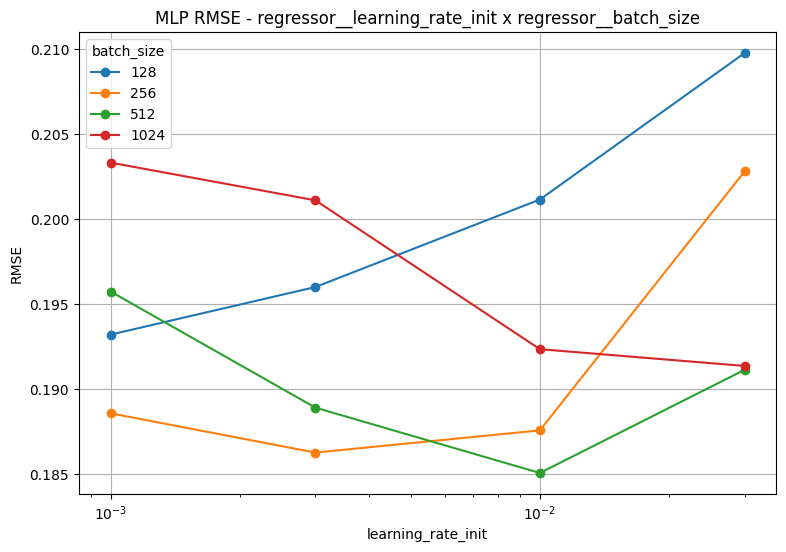

In [40]:
mlp_param_grid = {
  "regressor__learning_rate_init": [0.001, 0.003, 0.01, 0.03],
  "regressor__batch_size": [128, 256, 512, 1024],
  "regressor__alpha": [0.3],
  "regressor__hidden_layer_sizes": [(128, 64, 32)]
}

mlp_gridsearch, mlp_results = mlp_param_analysis(mlp_param_grid)

Here one can see that the best (lowest) validation RMSE comes from ``batch_size=512`` and ``learning_rate_init=0.01``.
Notice that this test was now conducted with the best values for hidden_layer_sizes and alpha that we found out before.

---

Next test: ``alpha`` again and ``activation``
- activation is the activation function for the hidden layer. It can be one of `identity`, `logistic`, `tanh`, or `relu`. **default=relu**
    
    here is a nice graphic about them: https://www.researchgate.net/profile/Christoph-Oberndorfer/publication/325115915/figure/fig9/AS:625915105132546@1526241198559/Overview-of-the-most-common-activation-functions-identity-binary-step-ReLU-logistic.png
    
    the identity function is not a non-linear transformation, so the entire neural network collapses to a linear model.

best found hyper-parameters: {'regressor__activation': 'relu', 'regressor__alpha': 0.2, 'regressor__batch_size': 512, 'regressor__hidden_layer_sizes': (128, 64, 32), 'regressor__learning_rate_init': 0.01}


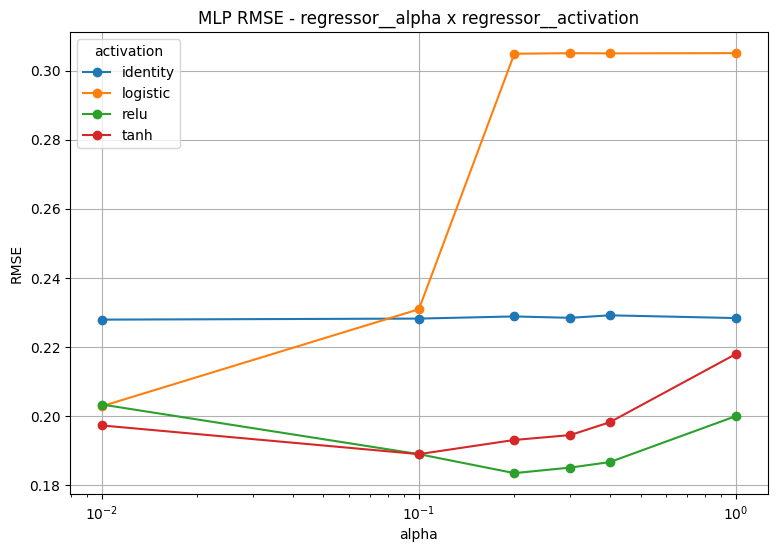

In [41]:
mlp_param_grid = {
  "regressor__alpha": [0.01, 0.1, 0.2, 0.3, 0.4, 1],
  "regressor__activation": ["identity", "logistic", "tanh", "relu"],
  "regressor__learning_rate_init": [0.01],
  "regressor__batch_size": [512],
  "regressor__hidden_layer_sizes": [(128, 64, 32)],
}

mlp_gridsearch, mlp_results = mlp_param_analysis(mlp_param_grid)

Surprisingly, identity is not even the worst.

Relu (the default) is the best, with an alpha of 0.2 (so with the current configuration we found a slightly better alpha)

---

,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,0.183463,0.006556,0.139286,0.00424,0.637139,0.030076


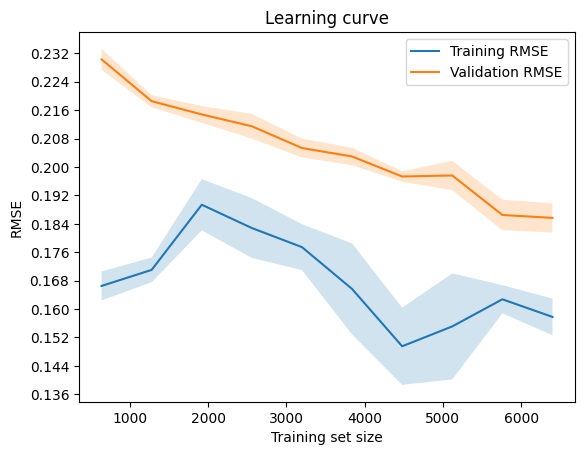

In [42]:
best_mlp_model = mlp_gridsearch.best_estimator_

display(validate_model(best_mlp_model, X_train, y_train))
plot_learning_curves(best_mlp_model, X_train, y_train)

test_model("MLP", y_test, best_mlp_model.predict(X_test))

This graph analyzes the strength of MLP for different training set sizes. The main takeaway here is that the validation score continuously goes down with increasing data size. This means, the chosen MLP model would be even better with more data, and possibly only later reach a plateau. so yippie

---

## 6. Evaluation

In [43]:
test_results_df()

,model,RMSE,MAE,R2
0,XGBoost,0.164031,0.124132,0.710449
1,MLP,0.187167,0.143121,0.623008
2,Linear Regression,0.230013,0.185124,0.430653
3,Gaussian Process Regression,0.275037,0.233342,0.185943
4,Constant (mean),0.304838,0.269922,-0.000023
5,Random (uniform),0.425584,0.347889,-0.949141


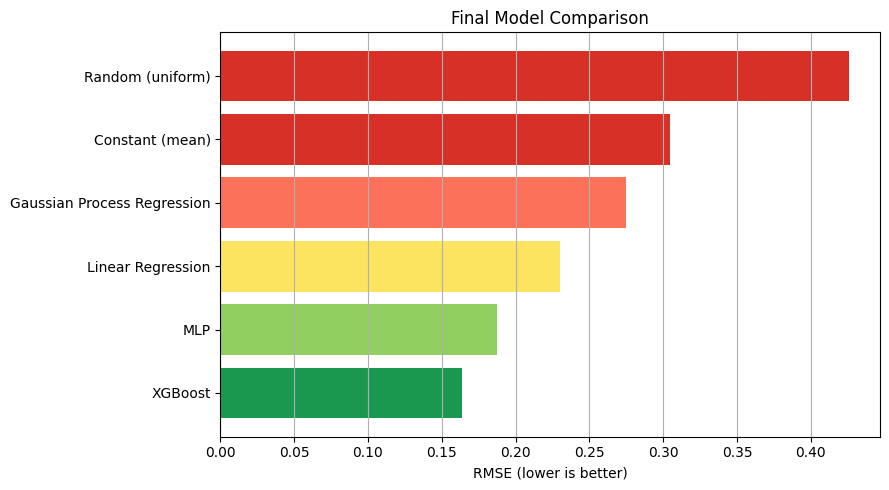

                      model      RMSE       MAE        R2
                    XGBoost  0.164031  0.124132  0.710449
                        MLP  0.187167  0.143121  0.623008
          Linear Regression  0.230013  0.185124  0.430653
Gaussian Process Regression  0.275037  0.233342  0.185943
            Constant (mean)  0.304838  0.269922 -0.000023
           Random (uniform)  0.425584  0.347889 -0.949141


In [60]:
plot_results = results.sort_values("RMSE")

colors = ["#1a9850", "#91cf60", "#fce461", "#fc7159", "#d73027", "#d73027"]
colors = colors[:len(plot_results)]

plt.figure(figsize=(9, 5))
plt.barh(plot_results["model"], plot_results["RMSE"], color=colors)

plt.xlabel("RMSE (lower is better)")
plt.ylabel("")
plt.title("Final Model Comparison")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

print(plot_results.to_string(index=False))

To finally conclude our evaluation, we would like to talk about the models and which we would choose for the prediction.

...